# 데이터의 불균형 문제에 대한 처리 방법
- 정상을 정확하게 분류하는 것과 이상을 정확하게 분류하는 것 중 이상을 정확하게 분류하는 것이 더 중요
- 보통 이상의 데이터를 target 데이터로 사용하는 경우가 많다.
- 데이터 불균형한 경우 분류의 성능과 target 데이터를 정확하게 분류하는 것에 일치하지 않는 부분이 발생(예측이 떨어진다.)
- 소수의 데이터의 중요도가 낮게 판단이 되서 실제 모델이 해당하는 예측을 적게 발생
- 이러한 경우에는 소수의 데이터를 증가시키는 오버 샘플링, 다수의 데이터에서 일부만 사용하는 언더 샘플링

In [1375]:
# 라이브러리 설치
# !pip install imbalanced-learn

- 언더 샘플링
    - 다수의 라벨을 가진 데이터를 샘플링하여 소수의 데이터의 수 수준으로 감소시키는 방법
    - 이 기법은 데이터 불균형 문제에 대한 해결은 되지만 전체 데이터 개수가 감소하여 학습의 성능을 떨어뜨릴 수 있다.

In [1376]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

In [1377]:
# 랜덤 데이터셋을 생성
# 90:10의 비율로 데이터를 생성

x, y = make_classification(
    n_samples=1000,
    n_features= 5,
    weights = [0.9],
    flip_y = 0
)

In [1378]:
x

array([[ 0.59121285,  0.61191674,  1.43939544, -0.93707576,  0.7008496 ],
       [-0.72564356, -0.74501334, -0.10254565,  1.08158262, -0.83188937],
       [-0.77494954, -0.54555299,  0.53458165, -1.68304091,  0.28382131],
       ...,
       [-1.43093104, -1.21845345, -0.57359246, -0.71200133, -0.46543463],
       [ 1.96576427,  1.88421047, -1.84135022, -1.40897344,  1.62534853],
       [-0.33814964, -0.09628117,  1.64017539, -2.34331655,  0.78838337]],
      shape=(1000, 5))

In [1379]:
y

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [1380]:
Counter(y)

Counter({np.int64(0): 901, np.int64(1): 99})

In [1381]:
df = pd.DataFrame(data = x)
df['target'] = y

df.head()

,0,1,2,3,4,target
0,0.591213,0.611917,1.439395,-0.937076,0.700850,1
1,-0.725644,-0.745013,-0.102546,1.081583,-0.831889,0
2,-0.774950,-0.545553,0.534582,-1.683041,0.283821,0
3,1.038664,1.022691,-1.132372,-1.052228,0.985911,1
4,-1.387139,-1.332180,0.685422,1.023631,-1.159065,0


In [1382]:
# RandomUnderSampler class 생성
undersampler = RandomUnderSampler()

In [1383]:
# undersampler 안에 있는 함수를 호출
x_under, y_under = undersampler.fit_resample(x, y)

In [1384]:
under_df = pd.DataFrame(data = x_under)

under_df['target'] = y_under

under_df['target'].value_counts()

target
0    99
1    99
Name: count, dtype: int64

In [1385]:
# undersampler에서 데이터의 비율을 변경
# class 생성시 비율을 지정
# sampling_strategy 매개변수 -> 소수의 데이터의 비율을 의미(다수의 데이터의 개수를 지정)
undersampler2 = RandomUnderSampler(sampling_strategy= 0.3)
x_under2, y_under2 = undersampler2.fit_resample(x, y)

In [1386]:
Counter(y_under2)

Counter({np.int64(0): 330, np.int64(1): 99})

- 오버샘플링
    - 소수의 데이터를 다수의 데이터의 개수만큼 증식시켜 학습에 사용하기 위한 방법
    - 데이터의 손실이 없기 떄문에 일반적으로 언더 샘플링에 비해 주로 사용

- 랜덤오버샘플링
    - 소수의 데이터를 단순 복제하여 다수의 데이터와의 비율을 맞춰주는 방법
    - 데이터가 단순 복제이기 때문에 분포가 변하지 않는다.
    - 단순하게 수가 증가하기 때문에 가중치 발생
    - 오버피팅의 위험성이 존재하지만 데이터 불균형 문제를 해결하는 것이 더 유효

In [1387]:
from imblearn.over_sampling import RandomOverSampler

In [1388]:
oversampler = RandomOverSampler()

In [1389]:
x_over, y_over = oversampler.fit_resample(x, y)

In [1390]:
Counter(y_over)

Counter({np.int64(1): 901, np.int64(0): 901})

- SMOTE
    - 소수의 데이터의 관측 값에 대한 K개의 최근접 양수를 이웃으로 찾고, 관측 값과 이웃으로 선택된 값 사이에 임의의 새로운 데이터를 생성하는 방법

In [1391]:
from imblearn.over_sampling import SMOTE

In [1392]:
smote_sampler = SMOTE()

In [1393]:
x_sm, y_sm = smote_sampler.fit_resample(x, y)

In [1394]:
Counter(y_sm)

Counter({np.int64(1): 901, np.int64(0): 901})

In [1395]:
import matplotlib.pyplot as plt
import seaborn as sns

In [1396]:
x[ : , 1]

array([ 0.61191674, -0.74501334, -0.54555299,  1.02269127, -1.33218048,
        0.37334918, -0.2367263 , -0.99423809, -0.27056544, -2.16060811,
       -1.76177307, -0.74692547, -1.70132733,  0.25241335, -0.35154348,
       -0.02460123, -1.28480197,  1.25051552, -0.94052534, -0.87288752,
       -1.23237211, -1.64127198, -0.35077658, -2.1580584 , -0.44401744,
       -0.21188004, -0.32281245, -0.96045394, -0.48764849, -0.11400534,
       -1.3738511 , -2.23439932, -0.93178824,  2.50524403, -0.1652626 ,
       -1.25503893, -1.48302203, -0.07964875, -0.2531959 , -0.9349873 ,
       -1.03869598, -1.16633824, -0.12609509, -1.29238049, -2.23693806,
       -0.54094194, -0.51245938, -2.01612941, -2.00711976, -1.49059328,
       -0.42105504, -0.8257057 , -1.25916901,  1.15175261, -0.76064942,
       -1.06529304, -0.98431452, -0.37314977, -1.10981601, -1.217622  ,
       -0.91872766, -1.42577941, -0.4811215 , -0.98632721, -1.0965968 ,
       -0.73357055, -0.37887662, -1.66241891, -0.06045547, -1.59

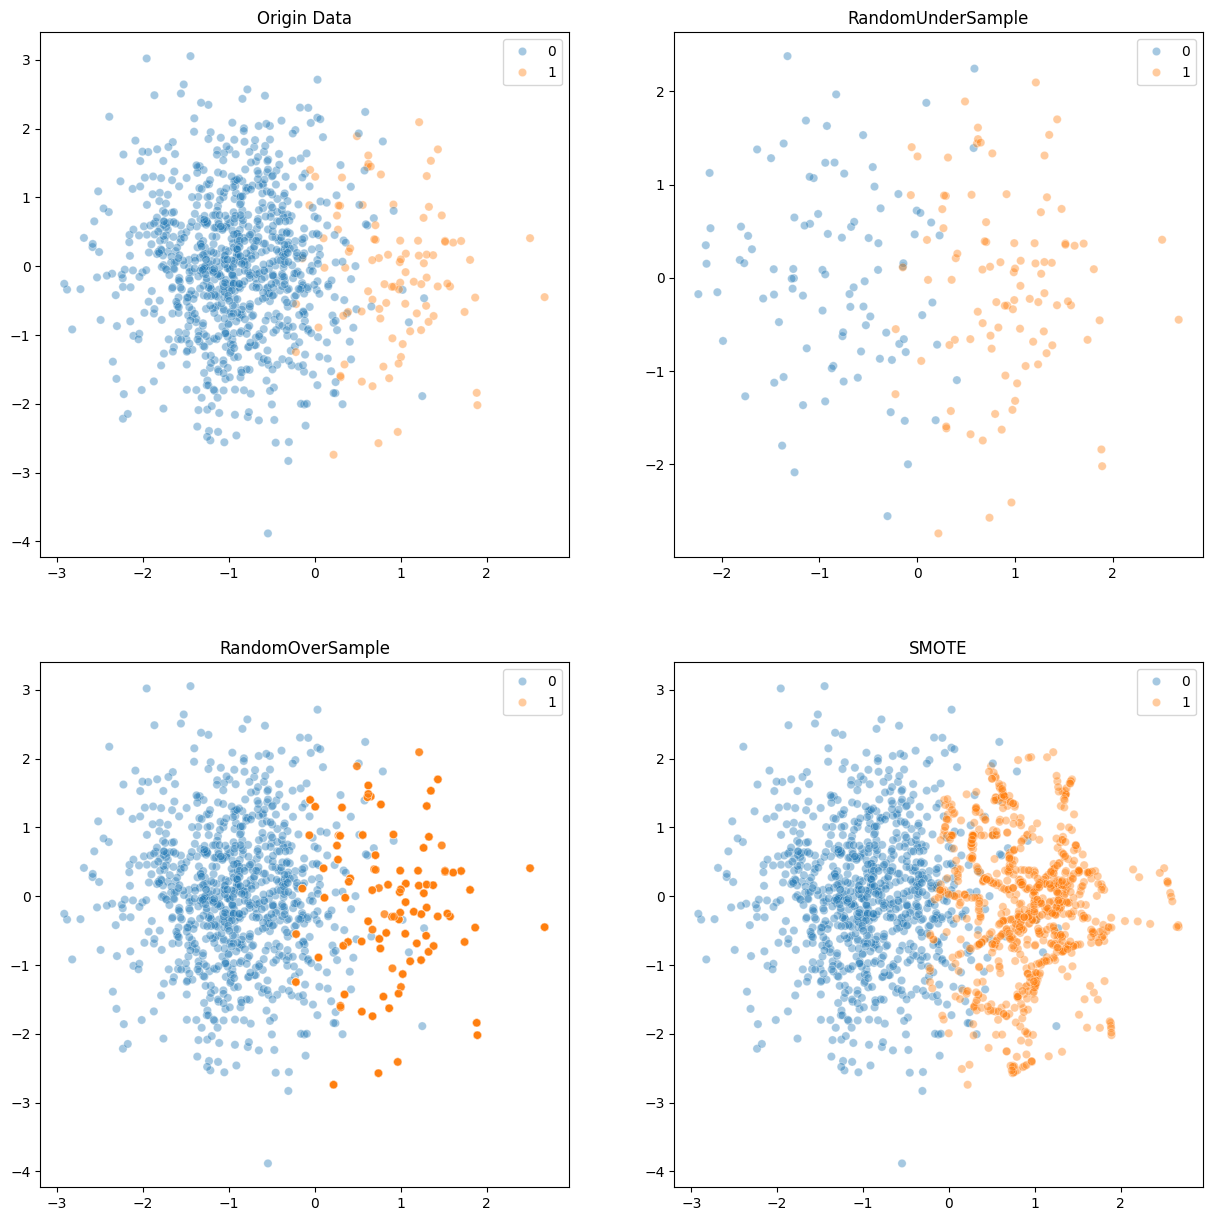

In [1397]:
# 도화지의 영역을 행을 2개 열로 2개로 나눈다.
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 15))

# 산점도 그래프를 생성
sns.scatterplot(
    x = x[:, 1], y = x[:, 2], ax = axes[0][0], hue = y, alpha = 0.4
)

sns.scatterplot(
    x = x_under[:, 1], y = x_under[:, 2], ax = axes[0][1], hue = y_under, alpha = 0.4
)
sns.scatterplot(
    x = x_over[:, 1], y = x_over[:, 2], ax = axes[1][0], hue = y_over, alpha = 0.4
)
sns.scatterplot(
    x = x_sm[:, 1], y = x_sm[:, 2], ax = axes[1][1], hue = y_sm, alpha = 0.4
)
axes[0][0].set_title('Origin Data')
axes[0][1].set_title('RandomUnderSample')
axes[1][0].set_title('RandomOverSample')
axes[1][1].set_title('SMOTE')

plt.show()